# 01 - BigSolDB 2.0 Data Setup

This notebook downloads/prepares a solvent-aware solubility dataset for dual-graph GNN training.

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
from rdkit import Chem

RAW_DIR = Path('../data/raw')
PROC_DIR = Path('../data/processed')
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROC_DIR.mkdir(parents=True, exist_ok=True)

DATA_URL = 'https://zenodo.org/records/15094979/files/BigSolDBv2.0.csv?download=1'
RAW_CSV = RAW_DIR / 'BigSolDBv2.0.csv'
PROCESSED_CSV = PROC_DIR / 'solubility_pairs.csv'

# Optional fallback: set this to a local CSV path if direct URL download is blocked.
MANUAL_CSV_PATH = None

In [2]:
# Download once (if not present)
if not RAW_CSV.exists():
    if MANUAL_CSV_PATH is not None and Path(MANUAL_CSV_PATH).exists():
        print('Using manual local CSV:', MANUAL_CSV_PATH)
        df_raw = pd.read_csv(MANUAL_CSV_PATH)
        df_raw.to_csv(RAW_CSV, index=False)
        print('Saved:', RAW_CSV)
    else:
        print('Downloading from:', DATA_URL)
        try:
            df_raw = pd.read_csv(DATA_URL)
            df_raw.to_csv(RAW_CSV, index=False)
            print('Saved:', RAW_CSV)
        except Exception as e:
            raise RuntimeError(
                'Could not download BigSolDB from URL. '
                'Set MANUAL_CSV_PATH to a local copy of BigSolDBv2.0.csv and rerun.'
            ) from e
else:
    print('Using existing file:', RAW_CSV)

df_raw = pd.read_csv(RAW_CSV)
print('Shape:', df_raw.shape)
print('Columns:', df_raw.columns.tolist())
df_raw.head()

Using existing file: ../data/raw/BigSolDBv2.0.csv
Shape: (103944, 12)
Columns: ['SMILES_Solute', 'Temperature_K', 'Solvent', 'SMILES_Solvent', 'Solubility(mole_fraction)', 'Solubility(mol/L)', 'LogS(mol/L)', 'Compound_Name', 'CAS', 'PubChem_CID', 'FDA_Approved', 'Source']


,SMILES_Solute,Temperature_K,Solvent,SMILES_Solvent,Solubility(mole_fraction),Solubility(mol/L),LogS(mol/L),Compound_Name,CAS,PubChem_CID,FDA_Approved,Source
0,CCCCCCCCCCCCCCCCCCCC(=O)OCCO,311.25,ethanol,CCO,0.0006,0.010083,-1.996419,Ethylene glycol monoeicosate,26158-80-5,538813.0,No,10.1007/bf00649573
1,CCCCCCCCCCCCCCCCCCCC(=O)OCCO,314.65,ethanol,CCO,0.0012,0.020100,-1.696799,Ethylene glycol monoeicosate,26158-80-5,538813.0,No,10.1007/bf00649573
2,CCCCCCCCCCCCCCCCCCCC(=O)OCCO,319.15,ethanol,CCO,0.0020,0.033356,-1.476824,Ethylene glycol monoeicosate,26158-80-5,538813.0,No,10.1007/bf00649573
3,CCCCCCCCCCCCCCCCCCCC(=O)OCCO,322.15,ethanol,CCO,0.0050,0.083356,-1.079064,Ethylene glycol monoeicosate,26158-80-5,538813.0,No,10.1007/bf00649573
4,CCCCCCCCCCCCCCCCCCCC(=O)OCCO,324.15,ethanol,CCO,0.0139,0.233286,-0.632111,Ethylene glycol monoeicosate,26158-80-5,538813.0,No,10.1007/bf00649573


In [3]:
# Flexible column mapping
solute_candidates = ['SMILES_Solute', 'solute_smiles', 'smiles_solute', 'solute_smile', 'solute']
solvent_candidates = ['SMILES_Solvent', 'solvent_smiles', 'smiles_solvent', 'solvent_smile', 'solvent']
logs_candidates = ['LogS(mol/L)', 'logS', 'log_s', 'logs', 'LogS']
solubility_candidates = ['Solubility(mol/L)', 'solubility_mol_l', 'solubility']
temp_candidates = ['T,K', 'temperature_k', 'Temperature(K)', 'temp_k', 'temperature']

def pick_col(cols, candidates):
    lower_map = {c.lower(): c for c in cols}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    return None

solute_col = pick_col(df_raw.columns, solute_candidates)
solvent_col = pick_col(df_raw.columns, solvent_candidates)
logs_col = pick_col(df_raw.columns, logs_candidates)
solubility_col = pick_col(df_raw.columns, solubility_candidates)
temp_col = pick_col(df_raw.columns, temp_candidates)

print('solute_col:', solute_col)
print('solvent_col:', solvent_col)
print('logs_col:', logs_col)
print('solubility_col:', solubility_col)
print('temp_col:', temp_col)

if solute_col is None or solvent_col is None:
    raise ValueError('Could not find required solute/solvent SMILES columns.')
if logs_col is None and solubility_col is None:
    raise ValueError('Could not find LogS or Solubility(mol/L) target column.')

solute_col: SMILES_Solute
solvent_col: SMILES_Solvent
logs_col: LogS(mol/L)
solubility_col: Solubility(mol/L)
temp_col: Temperature_K


In [4]:
df = df_raw[[solute_col, solvent_col] + ([logs_col] if logs_col else []) + ([solubility_col] if solubility_col else []) + ([temp_col] if temp_col else [])].copy()

df = df.rename(columns={
    solute_col: 'solute_smiles',
    solvent_col: 'solvent_smiles',
})

if logs_col:
    df = df.rename(columns={logs_col: 'logS'})
else:
    df['logS'] = np.log10(pd.to_numeric(df[solubility_col], errors='coerce'))

if temp_col:
    df = df.rename(columns={temp_col: 'temp_k'})
else:
    df['temp_k'] = np.nan

# keep only core columns
df = df[['solute_smiles', 'solvent_smiles', 'logS', 'temp_k']]

df['logS'] = pd.to_numeric(df['logS'], errors='coerce')
df = df.dropna(subset=['solute_smiles', 'solvent_smiles', 'logS']).reset_index(drop=True)

print('After cleanup:', df.shape)
df.head()

After cleanup: (100983, 4)


,solute_smiles,solvent_smiles,logS,temp_k
0,CCCCCCCCCCCCCCCCCCCC(=O)OCCO,CCO,-1.996419,311.25
1,CCCCCCCCCCCCCCCCCCCC(=O)OCCO,CCO,-1.696799,314.65
2,CCCCCCCCCCCCCCCCCCCC(=O)OCCO,CCO,-1.476824,319.15
3,CCCCCCCCCCCCCCCCCCCC(=O)OCCO,CCO,-1.079064,322.15
4,CCCCCCCCCCCCCCCCCCCC(=O)OCCO,CCO,-0.632111,324.15


In [5]:
def is_valid_smiles(s):
    return Chem.MolFromSmiles(str(s)) is not None

valid_solute = df['solute_smiles'].map(is_valid_smiles)
valid_solvent = df['solvent_smiles'].map(is_valid_smiles)

print('Invalid solute SMILES:', (~valid_solute).sum())
print('Invalid solvent SMILES:', (~valid_solvent).sum())

df = df[valid_solute & valid_solvent].reset_index(drop=True)
print('Final rows:', len(df))
print('Unique solvents:', df['solvent_smiles'].nunique())
print('logS range:', (df['logS'].min(), df['logS'].max()))

Invalid solute SMILES: 0
Invalid solvent SMILES: 0
Final rows: 100983
Unique solvents: 70
logS range: (-9.128882789071405, 2.4910710059840993)


In [6]:
df.to_csv(PROCESSED_CSV, index=False)
print('Saved processed dataset to:', PROCESSED_CSV)

Saved processed dataset to: ../data/processed/solubility_pairs.csv


Text(0, 0.5, 'Count')

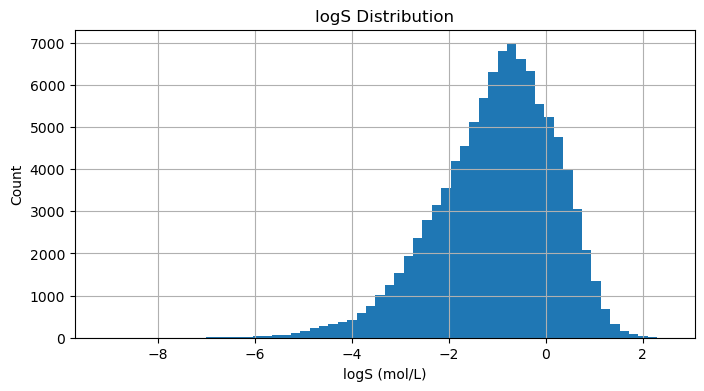

In [7]:
ax = df['logS'].hist(bins=60, figsize=(8,4))
ax.set_title('logS Distribution')
ax.set_xlabel('logS (mol/L)')
ax.set_ylabel('Count')